# OD Model Benchmark

Comparison pipeline: **our GPS-based model** (pre-trained in `gps_od.ipynb`) vs
paper baselines and classical/graph/diffusion baselines.

**Our model:** GPS-GNN encoder + decoder, loaded from pre-trained weights.
**Benchmark baselines:** training and inference are separated in this notebook.
Train baseline artifacts once, then compare them against GPS via load-only inference.

In [1]:
import pandas as pd

from benchmarking.config import (
    BASELINE_MODELS,
    BASELINE_TRAIN_TIMEOUT_SECONDS,
    DATA_PATH,
    GMEL_GPS_BENCHMARK_IDS,
    GPS_BENCHMARK_IDS,
    GPS_MC_BENCHMARK_IDS,
    INFERENCE_SEEDS,
    MULTI_CITY_IDS,
    PROJECT_ROOT,
    SINGLE_CITY_IDS,
    TRANSFLOWER_ORIG_CONFIG,
    WEIGHTS_CPC_BEST_DIR,
    WEIGHTS_DIR,
    cleanup_gpu,
    device,
    set_global_seed,
    trained_gps_run_ids,
    trained_multi_city_baseline_models,
    trained_single_city_baseline_models,
    trained_single_city_gps_run_ids,
    trained_single_city_lgbm_base_ids,
)
from benchmarking.data_utils import get_all_areas
from benchmarking.gps_loader import GPSBenchmarkLoader
from benchmarking.pipeline import (
    run_multi_city_benchmark,
    run_single_city_benchmark,
    train_multi_city_benchmark_models,
    train_single_city_benchmark_models,
)
from benchmarking.reporting import (
    build_combined_summary,
    plot_comparison,
    results_to_dataframe,
    save_results_table,
)

set_global_seed()

trained_sc = trained_single_city_gps_run_ids(GPS_BENCHMARK_IDS, SINGLE_CITY_IDS)
trained_sc_cpc_best = trained_single_city_gps_run_ids(
    GPS_BENCHMARK_IDS,
    SINGLE_CITY_IDS,
    weights_dir=WEIGHTS_CPC_BEST_DIR,
)
trained_mc = trained_gps_run_ids(GPS_MC_BENCHMARK_IDS)
trained_mc_cpc_best = trained_gps_run_ids(
    GPS_MC_BENCHMARK_IDS,
    weights_dir=WEIGHTS_CPC_BEST_DIR,
)
LGBM_BENCHMARK_IDS = trained_single_city_lgbm_base_ids(GPS_BENCHMARK_IDS, SINGLE_CITY_IDS)
gmel_gps_run_ids = trained_single_city_gps_run_ids(GMEL_GPS_BENCHMARK_IDS, SINGLE_CITY_IDS)
trained_sc_baselines = trained_single_city_baseline_models(BASELINE_MODELS, SINGLE_CITY_IDS)
trained_mc_baselines = trained_multi_city_baseline_models(BASELINE_MODELS)

single_city_baseline_train_runs = {}
multi_city_baseline_train_runs = {}
single_city_results = {}
single_city_model_type = {}
single_city_results_cpc_best = {}
single_city_model_type_cpc_best = {}
multi_city_results = {}
multi_city_model_type = {}
multi_city_results_cpc_best = {}
multi_city_model_type_cpc_best = {}
multi_city_split = None
multi_city_split_cpc_best = None
multi_city_training_split = None

gps_loader = GPSBenchmarkLoader(
    single_city_id=SINGLE_CITY_IDS[0],
    multi_city_ids=MULTI_CITY_IDS,
    data_path=DATA_PATH,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")
print(f"Data path: {DATA_PATH}")
print(f"Weights dir (val_loss): {WEIGHTS_DIR}")
print(f"Weights dir (CPC_nz_best): {WEIGHTS_CPC_BEST_DIR}")
print(f"Baseline train timeout: {BASELINE_TRAIN_TIMEOUT_SECONDS / 3600:.2f}h")

Project root: /home/rk/Документы/Python Projects/GSP_OD_Prediction
Device: cuda:1
Data path: /home/rk/Документы/Python Projects/GSP_OD_Prediction/data
Weights dir: /home/rk/Документы/Python Projects/GSP_OD_Prediction/results/weights


## Configurable Model List
Comment/uncomment to select which models to run.

In [3]:
print(f"GPS (SC) run_ids [weights]: {len(GPS_BENCHMARK_IDS)}  ({len(trained_sc)} fully trained across {len(SINGLE_CITY_IDS)} cities)")
print(f"GPS (SC) run_ids [weights_CPC_nz_best]: {len(GPS_BENCHMARK_IDS)}  ({len(trained_sc_cpc_best)} fully trained across {len(SINGLE_CITY_IDS)} cities)")
print(f"GPS (MC) run_ids [weights]: {len(GPS_MC_BENCHMARK_IDS)}  ({len(trained_mc)} trained)")
print(f"GPS (MC) run_ids [weights_CPC_nz_best]: {len(GPS_MC_BENCHMARK_IDS)}  ({len(trained_mc_cpc_best)} trained)")
print(f"LGBM donor ids:  {len(LGBM_BENCHMARK_IDS)}")
print(f"GMEL_GPS ids:    {len(gmel_gps_run_ids)}")
print(f"SC cities:       {SINGLE_CITY_IDS}")
print(f"Inference seeds: {INFERENCE_SEEDS}")
print(f"Baseline models: {len(BASELINE_MODELS)}")
print(f"SC baseline artifacts ready: {len(trained_sc_baselines)} / {len(BASELINE_MODELS)}")
print(f"MC baseline artifacts ready: {len(trained_mc_baselines)} / {len(BASELINE_MODELS)}")
print(f"SC baseline ready ids: {trained_sc_baselines}")
print(f"MC baseline ready ids: {trained_mc_baselines}")
print(f"TransFlower orig config: {TRANSFLOWER_ORIG_CONFIG.describe()}")

GPS (SC) run_ids: 1  (0 fully trained across 3 cities)
GPS (MC) run_ids: 1  (1 trained)
LGBM donor ids:  0
GMEL_GPS ids:    0
SC cities:       ['48201', '17031', '04013']
Inference seeds: [42, 43, 44, 45, 46]
Baseline models: 0
SC baseline artifacts ready: 0 / 0
MC baseline artifacts ready: 0 / 0
SC baseline ready ids: []
MC baseline ready ids: []
TransFlower orig config: MLP+transflower+ce+normalized | pe=rwpe | norm=batch_norm | RLE | zeros=True samp=False


In [ ]:
from dataclasses import asdict
import json

from models.GPS.config import load_model_config, WEIGHTS_DIR, WEIGHTS_CPC_BEST_DIR

run_id = "MC_BL_CE_lape_log_gn"

cfg = None
cfg_path = None

for weights_dir in (WEIGHTS_DIR, WEIGHTS_CPC_BEST_DIR):
    path = weights_dir / f"{run_id}.json"
    if path.exists():
        cfg = load_model_config(run_id, weights_dir=weights_dir)
        cfg_path = path
        break

if cfg is None:
    raise FileNotFoundError(
        f"Config for {run_id} not found.\n"
        f"Checked:\n"
        f"  - {WEIGHTS_DIR / f'{run_id}.json'}\n"
        f"  - {WEIGHTS_CPC_BEST_DIR / f'{run_id}.json'}"
    )

print(f"Loaded config from: {cfg_path}")
print(json.dumps(asdict(cfg), indent=2, ensure_ascii=False))

print("\nKey fields:")
for key in [
    "encoder_type",
    "decoder_type",
    "pe_type",
    "gps_norm_type",
    "loss_type",
    "prediction_mode",
    "use_log_transform",
    "use_dest_sampling",
    "n_dest_sample",
    "include_zero_pairs",
    "use_rle",
    "epochs",
    "mc_epochs",
]:
    print(f"{key}: {getattr(cfg, key)}")


## Single-City Benchmark

All models predict on the cities in `SINGLE_CITY_IDS`.
Training and inference are separated:
1. train/save baseline artifacts per city
2. run inference-only comparison against pre-trained GPS variants

In [5]:
# Single-city baseline training helper, split by benchmark city like in gps_od.ipynb
SC_CITY_1, SC_CITY_2, SC_CITY_3 = SINGLE_CITY_IDS
print(f"Single-city benchmark cities: {SINGLE_CITY_IDS}")

def train_sc_baseline_city(area_id):
    print()
    print("=" * 70)
    print(f"  SINGLE-CITY BASELINE TRAINING FOR {area_id}")
    print("=" * 70)
    city_runs = train_single_city_benchmark_models(
        single_city_ids=[area_id],
        data_path=DATA_PATH,
        baseline_models=BASELINE_MODELS,
        gps_loader=gps_loader,
    )
    single_city_baseline_train_runs[area_id] = city_runs
    trained_city_baselines = trained_single_city_baseline_models(BASELINE_MODELS, [area_id])
    print()
    print(f"Artifacts ready for {area_id}: {trained_city_baselines}")
    print(f"Training calls completed for {area_id}: {list(city_runs)}")
    return city_runs

Single-city benchmark cities: ['48201', '17031', '04013']


In [6]:
sc_city_1_baseline_runs = train_sc_baseline_city(SC_CITY_1)


  SINGLE-CITY BASELINE TRAINING FOR 48201

[Baseline training - single city]

Artifacts ready for 48201: []
Training calls completed for 48201: []


In [7]:
sc_city_2_baseline_runs = train_sc_baseline_city(SC_CITY_2)


  SINGLE-CITY BASELINE TRAINING FOR 17031

[Baseline training - single city]

Artifacts ready for 17031: []
Training calls completed for 17031: []


In [8]:
sc_city_3_baseline_runs = train_sc_baseline_city(SC_CITY_3)


  SINGLE-CITY BASELINE TRAINING FOR 04013

[Baseline training - single city]

Artifacts ready for 04013: []
Training calls completed for 04013: []


In [9]:
trained_sc_baselines = trained_single_city_baseline_models(BASELINE_MODELS, SINGLE_CITY_IDS)
print()
print(f"Artifacts ready across {SINGLE_CITY_IDS}: {trained_sc_baselines}")
print(f"Per-city training calls completed for: {list(single_city_baseline_train_runs)}")


Artifacts ready across ['48201', '17031', '04013']: []
Per-city training calls completed for: ['48201', '17031', '04013']


In [10]:
print("=" * 70)
print("  SINGLE-CITY BENCHMARK INFERENCE [weights]")
print(f"  Cities: {SINGLE_CITY_IDS}")
print(f"  Inference seeds: {INFERENCE_SEEDS}")
print("=" * 70)

trained_sc = trained_single_city_gps_run_ids(GPS_BENCHMARK_IDS, SINGLE_CITY_IDS)
trained_sc_baselines = trained_single_city_baseline_models(BASELINE_MODELS, SINGLE_CITY_IDS)
print(f"GPS artifacts available across all SC cities: {trained_sc}")
print(f"Baseline artifacts available: {trained_sc_baselines}")

single_city_results, single_city_model_type = run_single_city_benchmark(
    gps_run_ids=trained_sc,
    lgbm_run_ids=LGBM_BENCHMARK_IDS,
    single_city_ids=SINGLE_CITY_IDS,
    data_path=DATA_PATH,
    baseline_models=BASELINE_MODELS,
    gps_loader=gps_loader,
    gmel_gps_run_ids=gmel_gps_run_ids,
    inference_seeds=INFERENCE_SEEDS,
    gps_weights_dir=WEIGHTS_DIR,
    gps_model_type_label="Ours (GPS, val_loss)",
)

print()
print(f"Completed: {len(single_city_results)} models")

  SINGLE-CITY BENCHMARK INFERENCE
  Cities: ['48201', '17031', '04013']
  Inference seeds: [42, 43, 44, 45, 46]
Baseline artifacts available: []

[Our Model - GPS variants]
  Loading SC_TF_CE__city_48201 (pe_type=rwpe) ...
  SC_TF_CE__city_48201: CPC=0.7051  MAE=1.5131
  Loading SC_TF_CE__city_48201 (pe_type=rwpe) ...
  SC_TF_CE__city_48201: CPC=0.7051  MAE=1.5131
  Loading SC_TF_CE__city_48201 (pe_type=rwpe) ...
  SC_TF_CE__city_48201: CPC=0.7051  MAE=1.5131
  Loading SC_TF_CE__city_48201 (pe_type=rwpe) ...
  SC_TF_CE__city_48201: CPC=0.7051  MAE=1.5131
  Loading SC_TF_CE__city_48201 (pe_type=rwpe) ...
  SC_TF_CE__city_48201: CPC=0.7051  MAE=1.5131
  [SKIP] SC_TF_CE__city_17031: weights not found at /home/rk/Документы/Python Projects/GSP_OD_Prediction/results/weights/SC_TF_CE__city_17031.pt
  [SKIP] SC_TF_CE__city_17031: weights not found at /home/rk/Документы/Python Projects/GSP_OD_Prediction/results/weights/SC_TF_CE__city_17031.pt
  [SKIP] SC_TF_CE__city_17031: weights not found at 

In [11]:
if single_city_results:
    df_single = results_to_dataframe(single_city_results, single_city_model_type)

    print()
    print("=" * 100)
    print("  SINGLE-CITY RESULTS [weights] (3 cities, mean/std, sorted by CPC_full)")
    print("=" * 100)
    print(df_single.to_string())

    single_city_path = save_results_table(df_single, "single_city_benchmark_val_loss.csv")
    print()
    print(f"Saved to {single_city_path}")
else:
    print("No results to display.")


  SINGLE-CITY RESULTS (3 cities, mean/std, sorted by CPC)
               CPC       CPC_std  CPC_nonzero    CPC_nz    CPC_nz_std  CPC_test  CPC_test_std      RMSE      RMSE_std       MAE       MAE_std     MAPE      MAPE_std     SMAPE     SMAPE_std  MAE_test  MAE_test_std  RMSE_test  RMSE_test_std  accuracy  accuracy_std  matrix_COS_similarity  matrix_COS_similarity_std  JSD_inflow  JSD_inflow_std  JSD_outflow  JSD_outflow_std  JSD_ODflow  JSD_ODflow_std  n_runs  model_type
SC_TF_CE  0.705147  4.638792e-09     0.754632  0.754632  1.526020e-08  0.739509  4.427379e-09  4.588737  7.387253e-08  1.513137  2.089370e-08  0.53066  5.962925e-09  1.365166  1.551554e-09  2.547533  3.667541e-08   6.810175   2.186451e-07    0.7644           0.0               0.781428               1.971895e-09    0.025488    3.469447e-18          0.0              0.0    0.002178             0.0     5.0  Ours (GPS)

Saved to /home/rk/Документы/Python Projects/GSP_OD_Prediction/results/single_city_benchmark.csv


### Single-City Benchmark by `CPC_nz`-Best Weights

Runs only GPS checkpoints loaded from `results/weights_CPC_best`.
Baseline models stay the same; GPS+LGBM and GMEL_GPS are not included in this block.

In [ ]:
print("=" * 70)
print("  SINGLE-CITY BENCHMARK INFERENCE [weights_CPC_best]")
print(f"  Cities: {SINGLE_CITY_IDS}")
print(f"  Inference seeds: {INFERENCE_SEEDS}")
print("=" * 70)

trained_sc_cpc_best = trained_single_city_gps_run_ids(
    GPS_BENCHMARK_IDS,
    SINGLE_CITY_IDS,
    weights_dir=WEIGHTS_CPC_BEST_DIR,
)
trained_sc_baselines = trained_single_city_baseline_models(BASELINE_MODELS, SINGLE_CITY_IDS)
print(f"GPS CPC-best artifacts available across all SC cities: {trained_sc_cpc_best}")
print(f"Baseline artifacts available: {trained_sc_baselines}")

single_city_results_cpc_best, single_city_model_type_cpc_best = run_single_city_benchmark(
    gps_run_ids=trained_sc_cpc_best,
    lgbm_run_ids=[],
    single_city_ids=SINGLE_CITY_IDS,
    data_path=DATA_PATH,
    baseline_models=BASELINE_MODELS,
    gps_loader=gps_loader,
    gmel_gps_run_ids=[],
    inference_seeds=INFERENCE_SEEDS,
    gps_weights_dir=WEIGHTS_CPC_BEST_DIR,
    gps_model_type_label="Ours (GPS, CPC_nz-best)",
)

print()
print(f"Completed: {len(single_city_results_cpc_best)} models")

In [ ]:
if single_city_results_cpc_best:
    df_single_cpc_best = results_to_dataframe(single_city_results_cpc_best, single_city_model_type_cpc_best)

    print()
    print("=" * 100)
    print("  SINGLE-CITY RESULTS [weights_CPC_best] (3 cities, mean/std, sorted by CPC_full)")
    print("=" * 100)
    print(df_single_cpc_best.to_string())

    single_city_cpc_best_path = save_results_table(
        df_single_cpc_best,
        "single_city_benchmark_cpc_best.csv",
    )
    print()
    print(f"Saved to {single_city_cpc_best_path}")
else:
    print("No CPC_nz-best results to display.")

## Multi-City (8 Cities) Benchmark

8 cities, city-level split: 4 train, 2 val, 2 test, with New York and Memphis fixed as the multi-city test cities.
Training and inference are separated here as well:
1. train/save multi-city baseline artifacts
2. run inference-only comparison against pre-trained GPS variants

In [12]:
# Run this cell when you need to (re)train and save multi-city baseline artifacts.
print("=" * 70)
print("  MULTI-CITY BASELINE TRAINING")
print(f"  Cities: {MULTI_CITY_IDS}")
print(f"  Baselines: {BASELINE_MODELS}")
print("=" * 70)

multi_city_baseline_train_runs, multi_city_training_split = train_multi_city_benchmark_models(
    city_ids=MULTI_CITY_IDS,
    data_path=DATA_PATH,
    baseline_models=BASELINE_MODELS,
    gps_loader=gps_loader,
)

trained_mc_baselines = trained_multi_city_baseline_models(BASELINE_MODELS)
print()
print(f"Artifacts ready for {len(trained_mc_baselines)} baseline models: {trained_mc_baselines}")
print(f"Training calls completed for: {list(multi_city_baseline_train_runs)}")
print(f"Train: {multi_city_training_split['train']}")
print(f"Valid: {multi_city_training_split['valid']}")
print(f"Test:  {multi_city_training_split['test']}")

  MULTI-CITY BASELINE TRAINING
  Cities: ['17031', '48201', '04013', '06073', '06059', '36047', '12086', '48113', '06065', '36081']
  Baselines: []

[Baseline training - multi city]

Artifacts ready for 0 baseline models: []
Training calls completed for: []
Train: ['06065', '48201', '36047', '17031', '48113', '04013', '36081', '06059']
Valid: ['06073']
Test:  ['12086']


In [13]:
print("=" * 70)
print("  MULTI-CITY BENCHMARK INFERENCE [weights]")
print(f"  Cities: {MULTI_CITY_IDS}")
print(f"  Inference seeds: {INFERENCE_SEEDS}")
print("=" * 70)

trained_mc = trained_gps_run_ids(GPS_MC_BENCHMARK_IDS)
trained_mc_baselines = trained_multi_city_baseline_models(BASELINE_MODELS)
print(f"GPS MC artifacts available: {trained_mc}")
print(f"Baseline artifacts available: {trained_mc_baselines}")

multi_city_results, multi_city_model_type, multi_city_split = run_multi_city_benchmark(
    gps_run_ids=trained_mc,
    city_ids=MULTI_CITY_IDS,
    data_path=DATA_PATH,
    baseline_models=BASELINE_MODELS,
    gps_loader=gps_loader,
    inference_seeds=INFERENCE_SEEDS,
    gps_weights_dir=WEIGHTS_DIR,
    gps_model_type_label="Ours (GPS, val_loss)",
)

print(f"Train: {multi_city_split['train']}")
print(f"Valid: {multi_city_split['valid']}")
print(f"Test:  {multi_city_split['test']}")
print()
print(f"Completed: {len(multi_city_results)} models")

  MULTI-CITY BENCHMARK INFERENCE
  Cities: ['17031', '48201', '04013', '06073', '06059', '36047', '12086', '48113', '06065', '36081']
  Inference seeds: [42, 43, 44, 45, 46]
Baseline artifacts available: []

[Our Model - GPS variants]
  17031: N=1318
  48201: N=786
  04013: N=916
  06073: N=627
  06059: N=582
  36047: N=761
  12086: N=518
  48113: N=529
  06065: N=453
  36081: N=669
  06065: N=453
  48201: N=786
  36047: N=761
  17031: N=1318
  48113: N=529
  04013: N=916
  36081: N=669
  06059: N=582
  06073: N=627
  12086: N=518
  Loading MC_BL_CE_lape_log_gn (pe_type=lape) ...
  MC_BL_CE_lape_log_gn: CPC=0.3539  MAE=3.9958
  Loading MC_BL_CE_lape_log_gn (pe_type=lape) ...
  MC_BL_CE_lape_log_gn: CPC=0.3539  MAE=3.9958
  Loading MC_BL_CE_lape_log_gn (pe_type=lape) ...
  MC_BL_CE_lape_log_gn: CPC=0.3539  MAE=3.9958
  Loading MC_BL_CE_lape_log_gn (pe_type=lape) ...
  MC_BL_CE_lape_log_gn: CPC=0.3539  MAE=3.9958
  Loading MC_BL_CE_lape_log_gn (pe_type=lape) ...
  MC_BL_CE_lape_log_gn: C

In [14]:
if multi_city_results:
    df_multi = results_to_dataframe(multi_city_results, multi_city_model_type)

    print()
    print("=" * 100)
    print("  MULTI-CITY RESULTS [weights] (mean/std, sorted by CPC_full)")
    print("=" * 100)
    print(df_multi.to_string())

    multi_city_path = save_results_table(df_multi, "multi_city_benchmark_val_loss.csv")
    print()
    print(f"Saved to {multi_city_path}")
else:
    print("No results to display.")


  MULTI-CITY RESULTS (mean/std, sorted by CPC)
                           CPC       CPC_std  CPC_nonzero    CPC_nz    CPC_nz_std  CPC_test  CPC_test_std       RMSE      RMSE_std       MAE       MAE_std      MAPE      MAPE_std     SMAPE     SMAPE_std  MAE_test  MAE_test_std  RMSE_test  RMSE_test_std  accuracy  accuracy_std  matrix_COS_similarity  matrix_COS_similarity_std  JSD_inflow  JSD_inflow_std  JSD_outflow  JSD_outflow_std  JSD_ODflow  JSD_ODflow_std  n_runs  model_type
MC_BL_CE_lape_log_gn  0.353857  1.427908e-08     0.445763  0.445763  1.077920e-08  0.353857  1.427908e-08  11.820251  1.611798e-07  3.995798  6.556094e-08  1.667172  3.734635e-08  1.475749  6.155139e-09  3.995798  6.556094e-08  11.820251   1.611798e-07  0.550249           0.0               0.430098               1.211839e-08    0.091608             0.0          0.0              0.0    0.048424    2.251282e-09     5.0  Ours (GPS)

Saved to /home/rk/Документы/Python Projects/GSP_OD_Prediction/results/multi_city_benc

### Multi-City Benchmark by `CPC_nz`-Best Weights

Loads GPS checkpoints from `results/weights_CPC_best` and saves a separate benchmark table.

In [ ]:
print("=" * 70)
print("  MULTI-CITY BENCHMARK INFERENCE [weights_CPC_best]")
print(f"  Cities: {MULTI_CITY_IDS}")
print(f"  Inference seeds: {INFERENCE_SEEDS}")
print("=" * 70)

trained_mc_cpc_best = trained_gps_run_ids(
    GPS_MC_BENCHMARK_IDS,
    weights_dir=WEIGHTS_CPC_BEST_DIR,
)
trained_mc_baselines = trained_multi_city_baseline_models(BASELINE_MODELS)
print(f"GPS MC CPC-best artifacts available: {trained_mc_cpc_best}")
print(f"Baseline artifacts available: {trained_mc_baselines}")

multi_city_results_cpc_best, multi_city_model_type_cpc_best, multi_city_split_cpc_best = run_multi_city_benchmark(
    gps_run_ids=trained_mc_cpc_best,
    city_ids=MULTI_CITY_IDS,
    data_path=DATA_PATH,
    baseline_models=BASELINE_MODELS,
    gps_loader=gps_loader,
    inference_seeds=INFERENCE_SEEDS,
    gps_weights_dir=WEIGHTS_CPC_BEST_DIR,
    gps_model_type_label="Ours (GPS, CPC_nz-best)",
)

print(f"Train: {multi_city_split_cpc_best['train']}")
print(f"Valid: {multi_city_split_cpc_best['valid']}")
print(f"Test:  {multi_city_split_cpc_best['test']}")
print()
print(f"Completed: {len(multi_city_results_cpc_best)} models")

In [ ]:
if multi_city_results_cpc_best:
    df_multi_cpc_best = results_to_dataframe(multi_city_results_cpc_best, multi_city_model_type_cpc_best)

    print()
    print("=" * 100)
    print("  MULTI-CITY RESULTS [weights_CPC_best] (mean/std, sorted by CPC_full)")
    print("=" * 100)
    print(df_multi_cpc_best.to_string())

    multi_city_cpc_best_path = save_results_table(
        df_multi_cpc_best,
        "multi_city_benchmark_cpc_best.csv",
    )
    print()
    print(f"Saved to {multi_city_cpc_best_path}")
else:
    print("No CPC_nz-best results to display.")

## Visualization

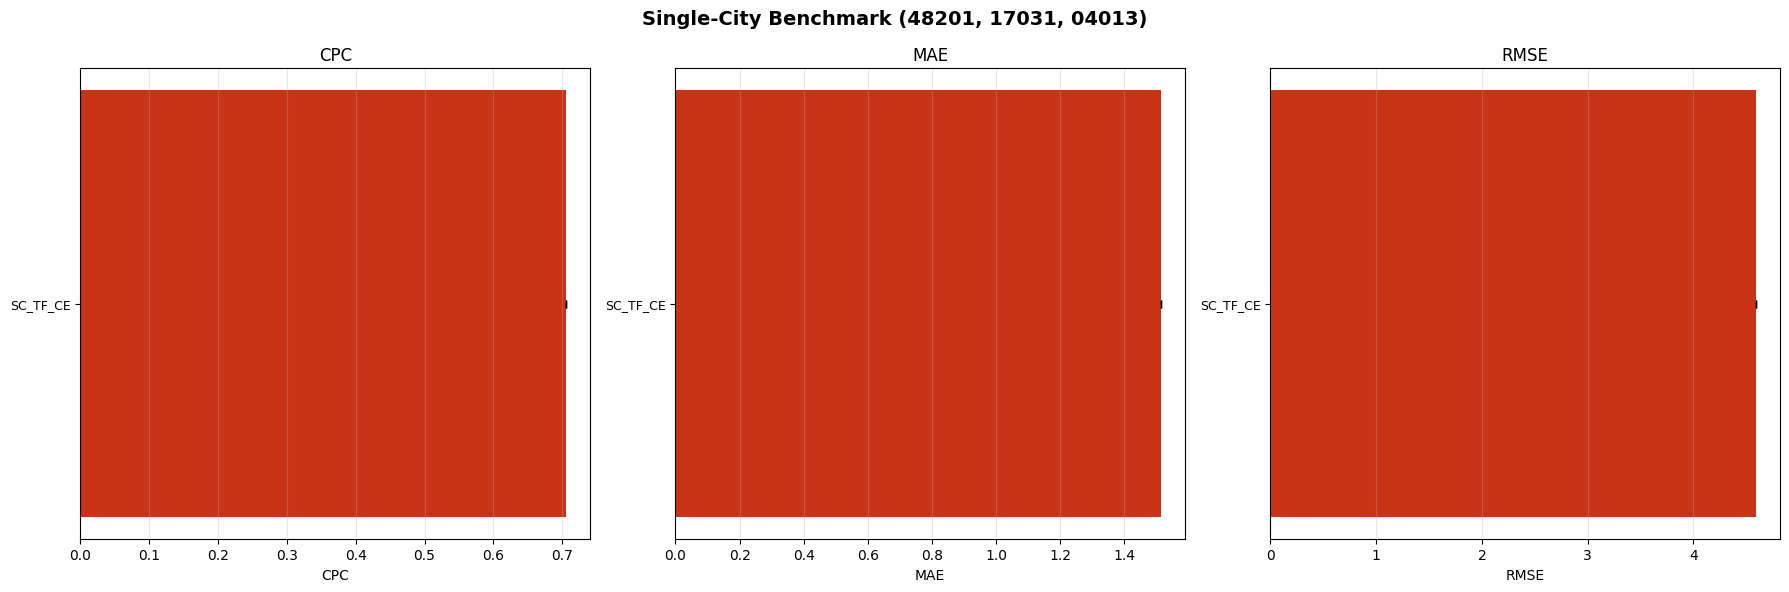

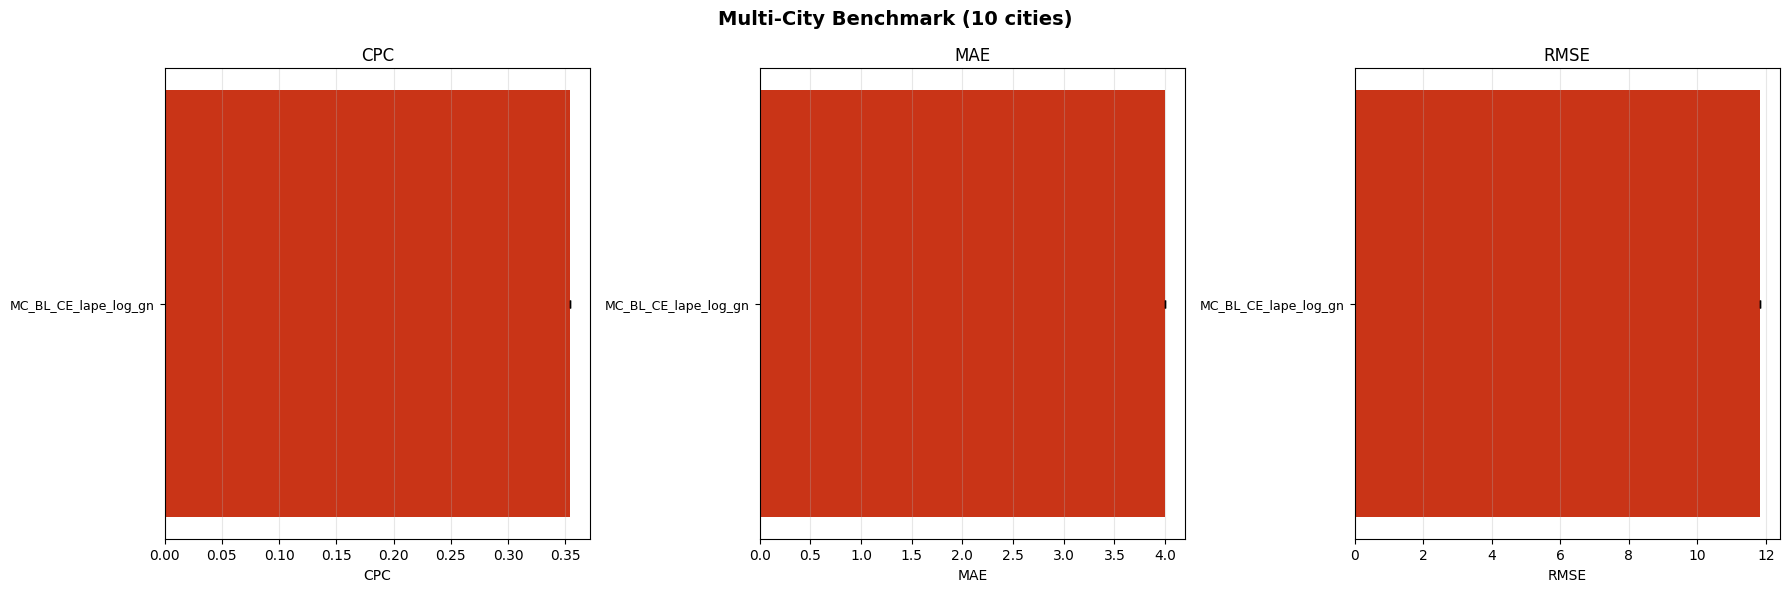

In [15]:
if single_city_results:
    plot_comparison(single_city_results, f"Single-City Benchmark ({', '.join(SINGLE_CITY_IDS)})", ["CPC_full", "MAE_full", "RMSE_full"])
if multi_city_results:
    plot_comparison(multi_city_results, f"Multi-City Benchmark ({len(MULTI_CITY_IDS)} cities)", ["CPC_full", "MAE_full", "RMSE_full"])

In [ ]:
if single_city_results_cpc_best and multi_city_results_cpc_best:
    print()
    print("=" * 120)
    print("  COMBINED SUMMARY [weights_CPC_best]")
    print("=" * 120)

    df_summary_cpc_best = build_combined_summary(
        single_city_results_cpc_best,
        multi_city_results_cpc_best,
    )
    print(df_summary_cpc_best.to_string())

    summary_cpc_best_path = save_results_table(
        df_summary_cpc_best,
        "benchmark_combined_cpc_best.csv",
    )
    print()
    print(f"Saved to {summary_cpc_best_path}")
else:
    print("Run both CPC_nz-best benchmark inference cells first.")

In [16]:
if single_city_results and multi_city_results:
    print()
    print("=" * 120)
    print("  COMBINED SUMMARY [weights]")
    print("=" * 120)

    df_summary = build_combined_summary(single_city_results, multi_city_results)
    print(df_summary.to_string())

    summary_path = save_results_table(df_summary, "benchmark_combined_val_loss.csv")
    print()
    print(f"Saved to {summary_path}")
else:
    print("Run both benchmark inference cells first.")


  COMBINED SUMMARY
                        MC_CPC    MC_CPC_std    MC_MAE    MC_MAE_std    MC_RMSE   MC_RMSE_std    SC_CPC    SC_CPC_std    SC_MAE    SC_MAE_std   SC_RMSE   SC_RMSE_std
Model                                                                                                                                                                
MC_BL_CE_lape_log_gn  0.353857  1.427908e-08  3.995798  6.556094e-08  11.820251  1.611798e-07       NaN           NaN       NaN           NaN       NaN           NaN
SC_TF_CE                   NaN           NaN       NaN           NaN        NaN           NaN  0.705147  4.638792e-09  1.513137  2.089370e-08  4.588737  7.387253e-08

Saved to /home/rk/Документы/Python Projects/GSP_OD_Prediction/results/benchmark_combined.csv
